COURSE QUALITY ANALYSIS PROJECT

Shape : (1947, 18)

Columns
['Course_ID', 'Course_Name', 'Department', 'Module', 'Lesson_Title', 'Content_Word_Count', 'Sentence_Count', 'Readability_Score', 'Grammar_Score', 'Learning_Objective_Match', 'Student_Rating', 'Completion_Rate', 'Feedback_Count', 'Reading_Time_Minutes', 'Publish_Date', 'Author', 'Difficulty_Level', 'Overall_Quality']

Data Types
Course_ID                    object
Course_Name                  object
Department                   object
Module                       object
Lesson_Title                 object
Content_Word_Count            int64
Sentence_Count              float64
Readability_Score           float64
Grammar_Score               float64
Learning_Objective_Match    float64
Student_Rating              float64
Completion_Rate             float64
Feedback_Count                int64
Reading_Time_Minutes          int64
Publish_Date                 object
Author                       object
Difficulty_Level             obj

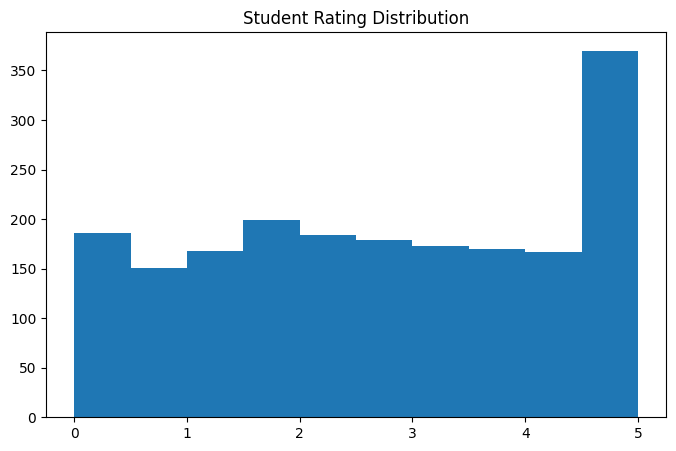

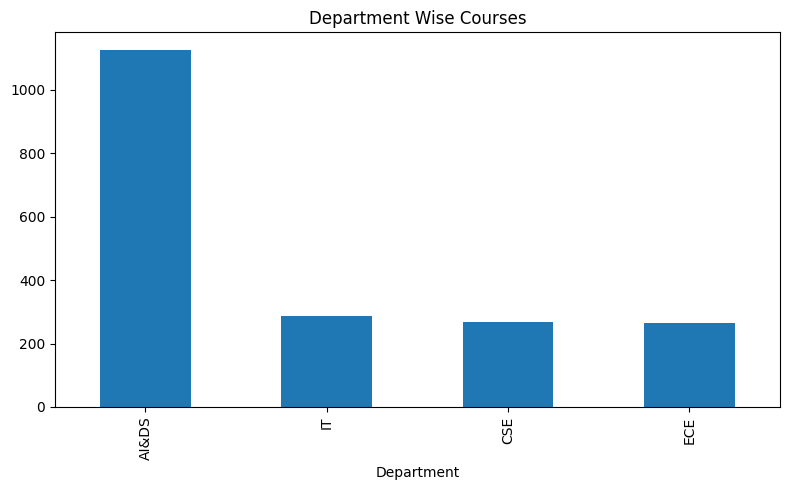

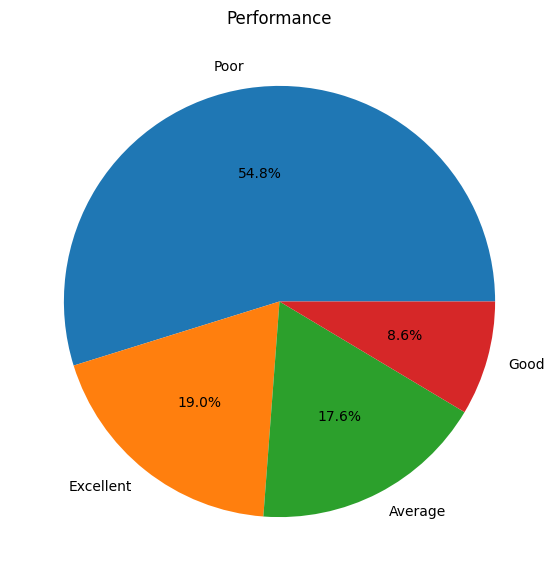

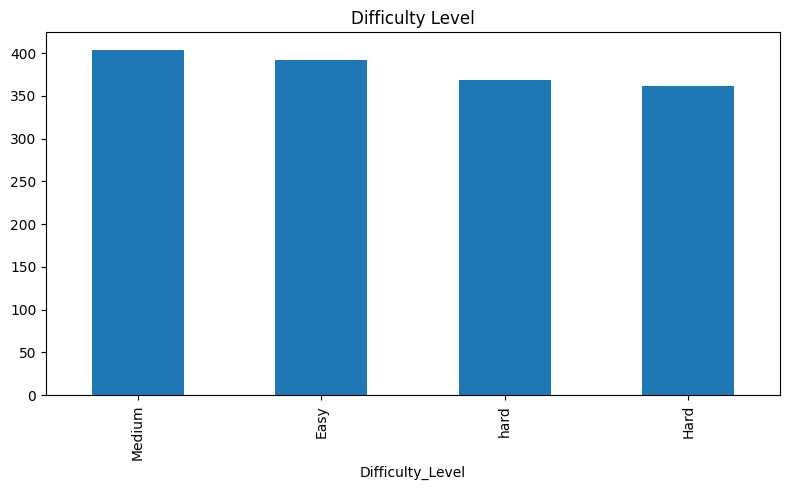

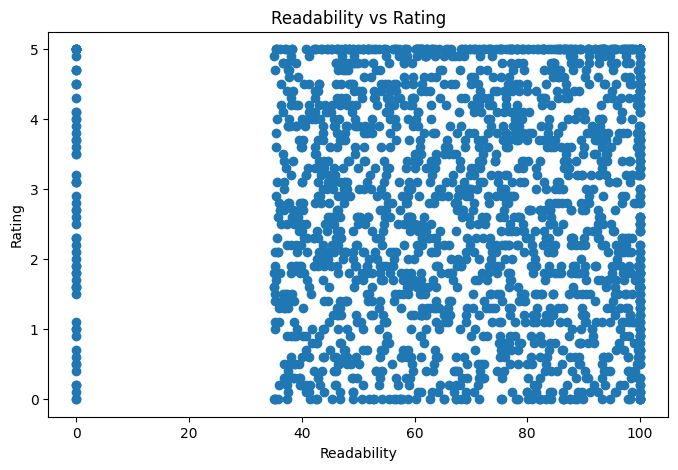

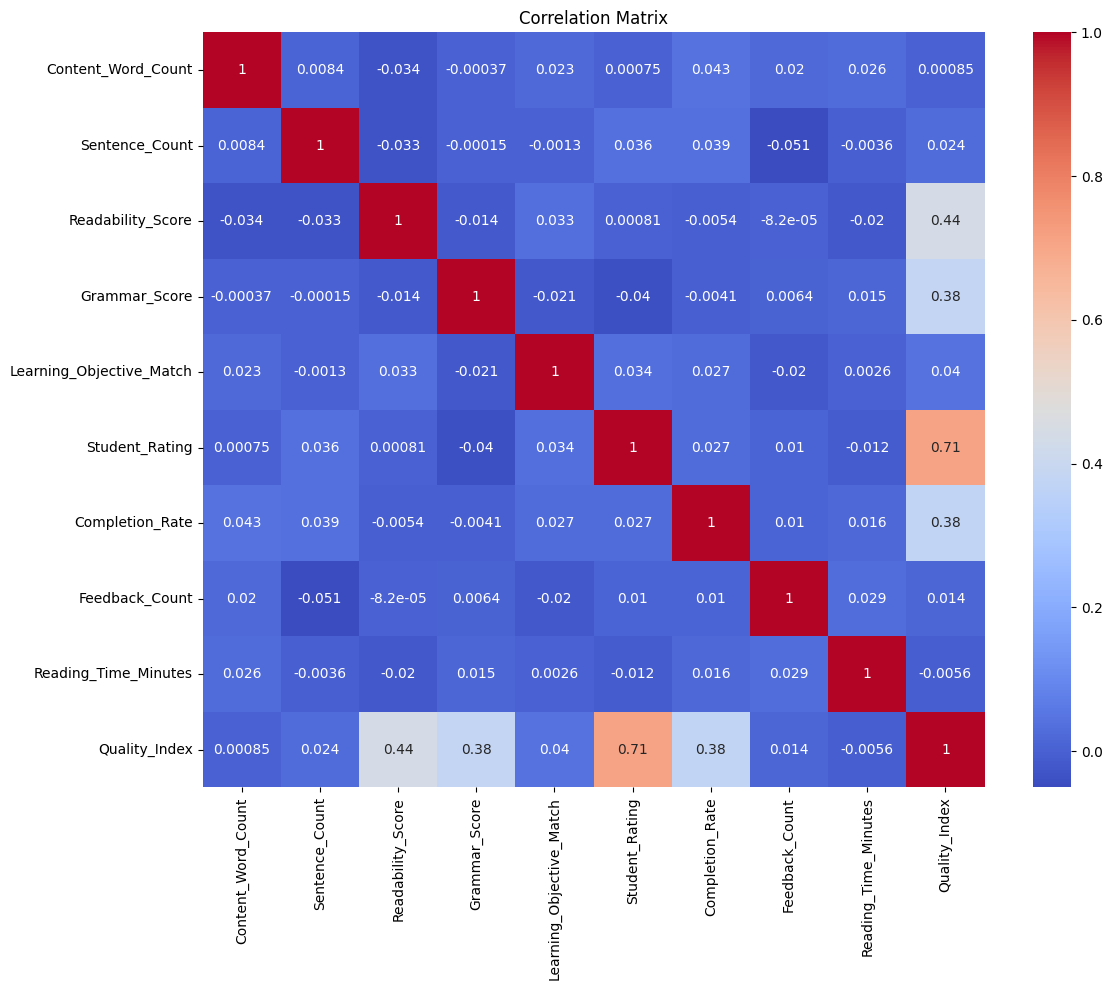

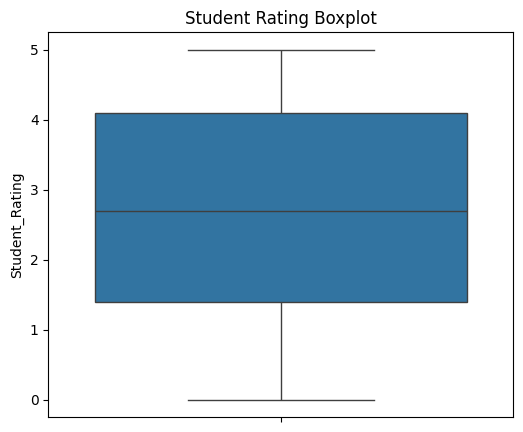

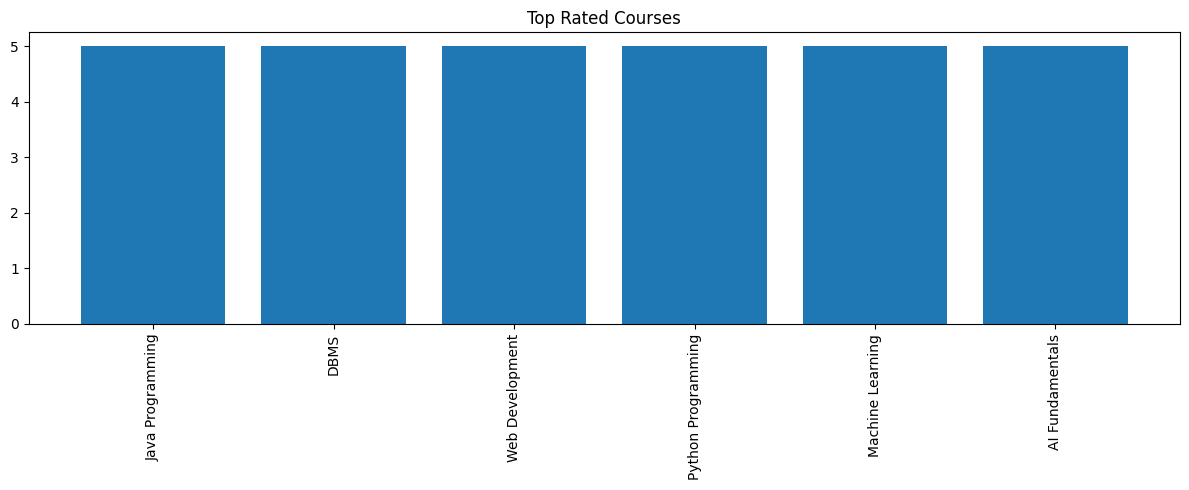


Dashboard Dataset Saved

Report Saved


PROJECT COMPLETED SUCCESSFULLY

Files Created
dashboard_dataset.csv
graphs/
reports/final_report.txt


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Create Folders
# ===============================

os.makedirs("graphs", exist_ok=True)
os.makedirs("reports", exist_ok=True)
os.makedirs("output", exist_ok=True)

# ===============================
# Load Dataset
# ===============================

df = pd.read_csv("Master_Education_Cleaned.csv")

print("="*70)
print("COURSE QUALITY ANALYSIS PROJECT")
print("="*70)

print("\nShape :", df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

print("\nStatistics")
print(df.describe())

# ===============================
# Feature Engineering
# ===============================

df["Quality_Index"] = (
    (df["Student_Rating"] * 20) * 0.30 +
    df["Grammar_Score"] * 0.25 +
    df["Readability_Score"] * 0.25 +
    df["Completion_Rate"] * 0.20
)

def performance(x):
    if x >= 4.5:
        return "Excellent"
    elif x >= 4:
        return "Good"
    elif x >= 3:
        return "Average"
    else:
        return "Poor"

df["Performance"] = df["Student_Rating"].apply(performance)

def completion(x):
    if x >= 90:
        return "Completed"
    elif x >= 60:
        return "In Progress"
    else:
        return "Needs Attention"

df["Completion_Status"] = df["Completion_Rate"].apply(completion)

def grammar(score):
    if score >= 90:
        return "Excellent"
    elif score >= 75:
        return "Good"
    else:
        return "Average"

df["Grammar_Category"] = df["Grammar_Score"].apply(grammar)

def readability(score):
    if score >= 80:
        return "Easy"
    elif score >= 60:
        return "Medium"
    else:
        return "Hard"

df["Readability_Category"] = df["Readability_Score"].apply(readability)

# ===============================
# KPI
# ===============================

print("\n================ KPI =================")

print("Total Courses :", len(df))

print("Average Rating :", round(df["Student_Rating"].mean(),2))

print("Average Grammar :", round(df["Grammar_Score"].mean(),2))

print("Average Readability :", round(df["Readability_Score"].mean(),2))

print("Average Completion :", round(df["Completion_Rate"].mean(),2))

print("Average Quality Index :", round(df["Quality_Index"].mean(),2))

print("Total Feedback :", df["Feedback_Count"].sum())

# ===============================
# Graph 1
# ===============================

plt.figure(figsize=(8,5))
plt.hist(df["Student_Rating"],bins=10)
plt.title("Student Rating Distribution")
plt.savefig("graphs/rating_distribution.png")
plt.show()

# ===============================
# Graph 2
# ===============================

plt.figure(figsize=(8,5))
df["Department"].value_counts().plot(kind="bar")
plt.title("Department Wise Courses")
plt.tight_layout()
plt.savefig("graphs/departments.png")
plt.show()

# ===============================
# Graph 3
# ===============================

plt.figure(figsize=(7,7))
df["Performance"].value_counts().plot(
kind="pie",
autopct="%1.1f%%"
)
plt.ylabel("")
plt.title("Performance")
plt.savefig("graphs/performance.png")
plt.show()

# ===============================
# Graph 4
# ===============================

plt.figure(figsize=(8,5))
df["Difficulty_Level"].value_counts().plot(kind="bar")
plt.title("Difficulty Level")
plt.tight_layout()
plt.savefig("graphs/difficulty.png")
plt.show()

# ===============================
# Graph 5
# ===============================

plt.figure(figsize=(8,5))
plt.scatter(
df["Readability_Score"],
df["Student_Rating"]
)
plt.xlabel("Readability")
plt.ylabel("Rating")
plt.title("Readability vs Rating")
plt.savefig("graphs/readability_vs_rating.png")
plt.show()

# ===============================
# Graph 6
# ===============================

numeric=df.select_dtypes(include=np.number)

corr=numeric.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
corr,
annot=True,
cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig("graphs/correlation.png")

plt.show()

# ===============================
# Graph 7
# ===============================

plt.figure(figsize=(6,5))

sns.boxplot(y=df["Student_Rating"])

plt.title("Student Rating Boxplot")

plt.savefig("graphs/box_rating.png")

plt.show()

# ===============================
# Top Courses
# ===============================

top=df.sort_values(
"Student_Rating",
ascending=False
).head(10)

plt.figure(figsize=(12,5))

plt.bar(
top["Course_Name"],
top["Student_Rating"]
)

plt.xticks(rotation=90)

plt.title("Top Rated Courses")

plt.tight_layout()

plt.savefig("graphs/top_courses.png")

plt.show()

# ===============================
# Dashboard Dataset
# ===============================

df.to_csv(
"dashboard_dataset.csv",
index=False
)

print("\nDashboard Dataset Saved")

# ===============================
# Report
# ===============================

report=[]

report.append("COURSE QUALITY ANALYSIS REPORT")

report.append("="*60)

report.append(f"\nTotal Courses : {len(df)}")

report.append(f"\nAverage Rating : {round(df['Student_Rating'].mean(),2)}")

report.append(f"\nAverage Grammar : {round(df['Grammar_Score'].mean(),2)}")

report.append(f"\nAverage Readability : {round(df['Readability_Score'].mean(),2)}")

report.append(f"\nAverage Completion : {round(df['Completion_Rate'].mean(),2)}")

report.append(f"\nAverage Quality Index : {round(df['Quality_Index'].mean(),2)}")

report.append("\n\nPerformance Distribution\n")

report.append(str(df["Performance"].value_counts()))

report.append("\n\nCompletion Status\n")

report.append(str(df["Completion_Status"].value_counts()))

report.append("\n\nDepartment Wise Rating\n")

report.append(str(

df.groupby("Department")["Student_Rating"]

.mean()

.sort_values(ascending=False)

))

report.append("\n\nTop Authors\n")

report.append(str(

df.groupby("Author")["Student_Rating"]

.mean()

.sort_values(ascending=False)

.head(10)

))

with open(
"reports/final_report.txt",
"w"
) as f:

    f.write("\n".join(report))

print("\nReport Saved")

print("\n")

print("="*70)

print("PROJECT COMPLETED SUCCESSFULLY")

print("="*70)

print("\nFiles Created")

print("dashboard_dataset.csv")

print("graphs/")

print("reports/final_report.txt")